In [1]:
!git clone https://github.com/Otza02/land2vec.git
%cd /content/land2vec
!pip install -e .

Cloning into 'land2vec'...
remote: Enumerating objects: 203, done.
remote: Counting objects: 100% (203/203), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 203 (delta 91), reused 167 (delta 62), pack-reused 0 (from 0)
Receiving objects: 100% (203/203), 6.97 MiB | 20.58 MiB/s, done.
Resolving deltas: 100% (91/91), done.
/content/land2vec
Obtaining file:///content/land2vec
  Preparing metadata (setup.py) ... done
  Running setup.py develop for land2vec


### ---Restart session before next cell---

In [1]:
%cd /content/land2vec

/content/land2vec


In [14]:
import tqdm
from datetime import datetime
import pandas as pd
import numpy as np
import os
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import lr_scheduler

from land2vec.dataset import load_data, SequenceDataset
from land2vec.config import Config
from land2vec.model import GPTDecoder, run_epoch
from land2vec.tokenizer import Tokenizer
from land2vec.utils import get_target_folder, load_config, load_model, load_train_results, save_config, save_model, save_train_results

In [3]:
config = Config(patience=4, device="cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(config.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.seed)
    torch.backends.cuda.enable_flash_sdp(True)
    torch.backends.cuda.enable_mem_efficient_sdp(True)
config.device

'cuda'

In [4]:
print("loading data")
file_path = "data/id_seqs_text_2000_2022_chaco_santiago_frontier.zip"
try:
    dataset = load_data(file_path="/content/land2vec/" + file_path, window=config.block_size)
except FileNotFoundError:
    dataset = load_data(file_path="../data/seqs_short.csv", window=config.block_size)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

generator = torch.Generator().manual_seed(config.seed)

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size], generator=generator)
loader_kwargs = dict(
    batch_size=config.batch_size,
    num_workers=config.num_workers,
    pin_memory=True,
    persistent_workers=True,
)

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs,
)

loading data


100%|██████████| 1424457/1424457 [00:17<00:00, 79196.88it/s]


In [5]:
config

Config(block_size=12, n_embd=128, n_head=4, n_layer=4, dropout=0.1, epochs=25, patience=4, lr=0.001, min_lr=1e-06, weight_decay=0.01, num_workers=2, batch_size=256, device='cuda', seed=42)

In [ ]:
model = GPTDecoder(
    vocab_size=len(Tokenizer.VOCAB),
    block_size=config.block_size,
    n_embd=config.n_embd,
    n_head=config.n_head,
    n_layer=config.n_layer,
    dropout=config.dropout,
).to(config.device)

optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay, fused=config.device == "cuda")
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs, eta_min=config.min_lr)
scaler = torch.amp.GradScaler(enabled=True) if config.device == "cuda" else None

print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

parameters: 794,880


In [ ]:
best_model_state = None
best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_ppl": [],
    "lr": [],
    "epoch_time": [],
    "tokens_per_sec": [],
}

global_start = datetime.now()
for epoch in range(config.epochs):
    start = datetime.now()
    train_loss = run_epoch(model, train_loader, optimizer, config.device, scaler=scaler, use_amp=True)
    val_loss = run_epoch(model, val_loader, optimizer=None, device=config.device, scaler=None, use_amp=True)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    epoch_seconds = (datetime.now() - start).seconds
    if epoch_seconds < 1:
        epoch_seconds = 1

    tokens_processed = (len(train_loader.dataset) * config.block_size)
    tokens_per_sec = (tokens_processed / epoch_seconds)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_ppl"].append(torch.math.exp(val_loss))
    history["lr"].append(current_lr)
    history["epoch_time"].append(epoch_seconds)
    history["tokens_per_sec"].append(tokens_per_sec)

    ppl = torch.math.exp(val_loss)
    print(
        f"[Epoch {epoch+1:03d}] | "
        f"train={train_loss:.4f} | "
        f"val={val_loss:.4f} | "
        f"ppl={ppl:.3f} | "
        f"lr={current_lr:.2e} | "
        f"time={(epoch_seconds // 60):02}:{(epoch_seconds % 60):02} | "
        f"token/s={tokens_per_sec:,.0f} | "
    )

    if patience_counter >= config.patience:
        print("Early stopping...")
        model.load_state_dict(best_model_state)
        break

total_time = (datetime.now() - global_start).seconds
print("=== Finished Training ===")
print(f"best epoch: {best_epoch}")
print(f"best val loss: {best_val_loss:.4f}")
print(f"total training time: {total_time // 60:02}:{total_time % 60:02}")

c:\Users\Admin\Desktop\unsam\proyecto\land2vec\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[Epoch 001] | train=3.8895 | val=0.0000 | ppl=48.885 | lr=9.96e-04 | time=00:04 | token/s=24 | 
[Epoch 002] | train=1.6102 | val=2.0557 | ppl=5.004 | lr=9.84e-04 | time=00:01 | token/s=96 | 
[Epoch 003] | train=1.6950 | val=0.0000 | ppl=5.447 | lr=9.65e-04 | time=00:01 | token/s=96 | 
[Epoch 004] | train=0.8794 | val=0.0000 | ppl=2.409 | lr=9.38e-04 | time=00:01 | token/s=96 | 
[Epoch 005] | train=1.2627 | val=0.0000 | ppl=3.535 | lr=9.05e-04 | time=00:01 | token/s=96 | 
Early stopping...
=== Finished Training ===
best epoch: 1
best val loss: 0.0000
total training time: 00:05


In [ ]:
target_folder = get_target_folder(str(datetime.now().date()))

In [ ]:
# torch.save(model.state_dict(), "first-test.pt")
os.makedirs(str(target_folder), exist_ok=True)
save_config(config, target_folder)
save_model(model, target_folder)
save_train_results(history, target_folder)

Config saved to ..\models\2026-05-19\config.json
Model saved to ..\models\2026-05-19\model.pt
Train data saved to ..\models\2026-05-19\train_data.csv


## Load model

In [15]:
print(get_target_folder("2026-05-20"))
print(os.getcwd())
print(os.listdir(os.path.join("models")))
target_folder = Path("models") / "2026-05-20"
target_folder

../models/2026-05-20
/content/land2vec
['first-test.pt', '2026-05-20']


PosixPath('models/2026-05-20')

In [16]:

load_config(target_folder)

Config(block_size=12, n_embd=128, n_head=4, n_layer=4, dropout=0.1, epochs=25, patience=4, lr=0.001, min_lr=1e-06, weight_decay=0.01, num_workers=2, batch_size=256, device='cuda', seed=42)

## Train evaluation

In [17]:
config = load_config(target_folder)
model = load_model(config, target_folder)
train_results = load_train_results(target_folder)

In [18]:
train_results.head()

,train_loss,val_loss,lr,epoch_time,tokens_per_sec
0,0.035851,0.032209,0.000996,68,201099.705882
1,0.032404,0.032436,0.000984,67,204101.194030
2,0.032171,0.032120,0.000965,68,201099.705882
3,0.032055,0.032138,0.000938,67,204101.194030
4,0.031995,0.032229,0.000905,67,204101.194030


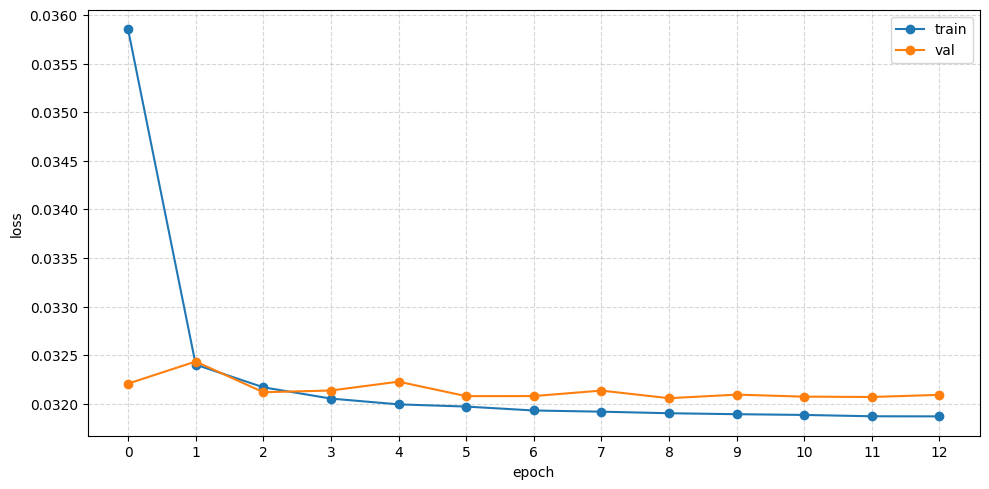

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_results["train_loss"], label="train", marker="o")
ax.plot(train_results["val_loss"], label="val", marker="o")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_xticks(range(len(train_results["train_loss"])))
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()

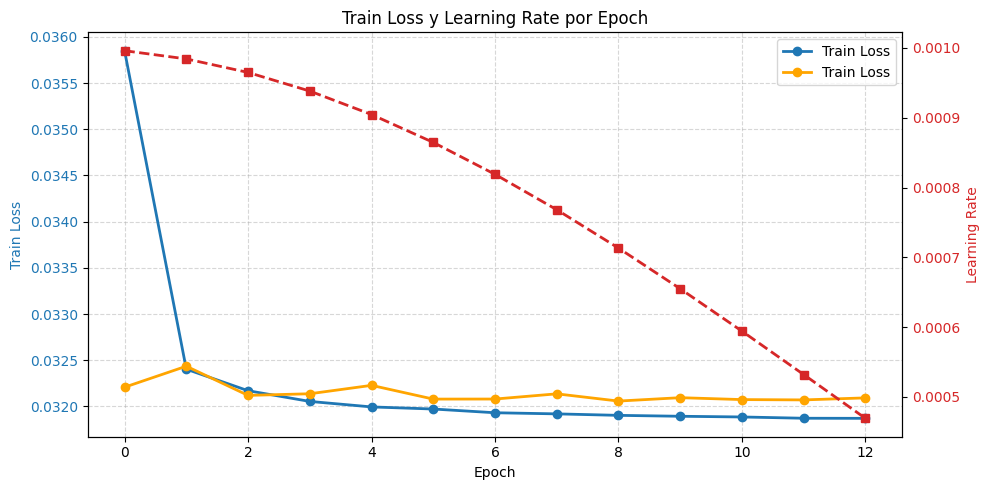

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# ----- Eje Y izquierdo (train loss) -----
color1 = 'tab:blue'

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=color1)

ax1.plot(train_results["train_loss"],color=color1 ,marker='o', linewidth=2, label='Train Loss')
ax1.plot(train_results["val_loss"],color="orange" ,marker='o', linewidth=2, label='Train Loss')

ax1.tick_params(axis='y', labelcolor=color1)
ax1.legend(loc='upper right')

# ----- Eje Y derecho (learning rate) -----
ax2 = ax1.twinx()

color2 = 'tab:red'

ax2.set_ylabel('Learning Rate', color=color2)
ax2.plot(train_results["lr"], color=color2, marker='s', linestyle='--', linewidth=2, label='Learning Rate')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Train Loss y Learning Rate por Epoch')
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

KeyError: 'val_ppl'

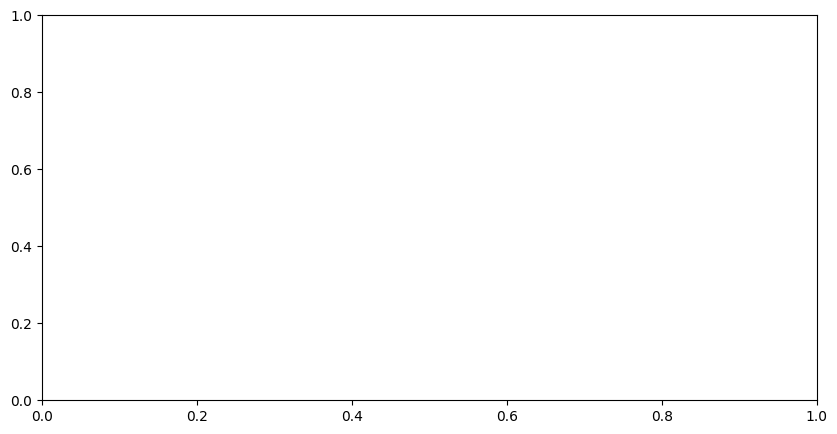

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_results["val_ppl"], label="val", marker="o")
ax.set_xlabel("epoch")
ax.set_ylabel("ppl")
ax.set_xticks(range(len(train_results["val_ppl"])))
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()

## Predicción



In [20]:
@torch.no_grad()
def predict_next(model, idx):
    model.eval()
    logits, _ = model(idx)
    logits = logits[:, -1, :]
    probs = torch.softmax(logits, dim=-1)
    pred = logits.argmax(dim=-1)
    return pred, probs

@torch.no_grad()
def next_token_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits, _ = model(x)
        preds = logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.numel()
    return correct / total

In [21]:
next_token_accuracy(model, test_loader, config.device)

0.9954105737572571

In [ ]:
@torch.no_grad()
def accuracy_by_position(model, loader, device):
    model.eval()
    acc_sum = 0
    batches = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits, _ = model(x)
        preds = logits.argmax(dim=-1)
        correct = (preds == y).float()
        pos_acc = correct.mean(dim=0)
        acc_sum += pos_acc
        batches += 1
    return (acc_sum / batches).cpu()

In [24]:
pos_acc = accuracy_by_position(model, test_loader, config.device)
pos_acc

tensor([0.9951, 0.9951, 0.9953, 0.9953, 0.9955, 0.9953, 0.9952, 0.9950, 0.9952,
        0.9956, 0.9959, 0.9965])

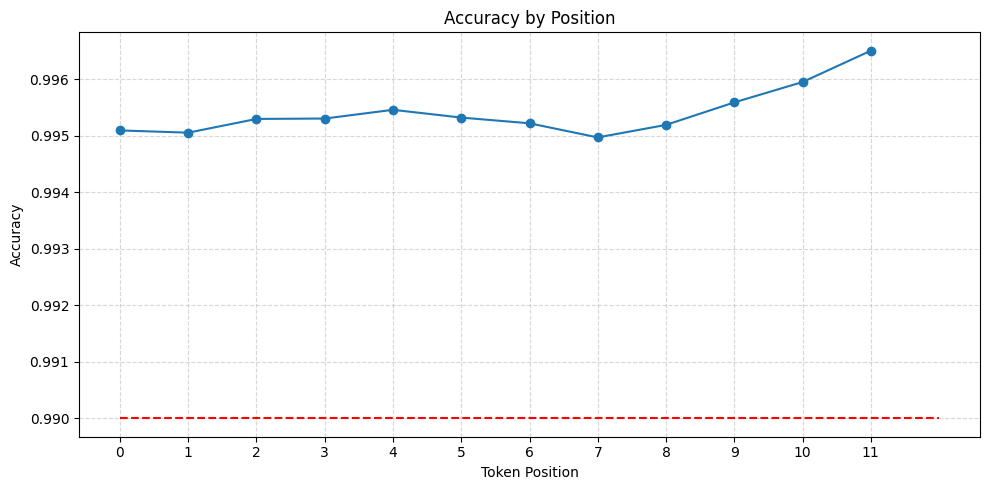

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pos_acc, marker="o")
ax.hlines([0.99], 0, len(pos_acc), linestyles=["--"], colors=["red"])

ax.set_xlabel("Token Position")
ax.set_ylabel("Accuracy")
ax.set_xticks(range(len(pos_acc)))
ax.grid(True, linestyle='--', alpha=0.5)
plt.title("Accuracy by Position")
plt.tight_layout()
plt.show()